In [1]:
import torch
import numpy as np
import shutil
import boto3
from functools import partial

from torch.utils.data import DataLoader
from cryo_ml_utils.data.cryo_ppp.dataset import CryoPPPDataset

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [6]:
s3 = boto3.client(
    "s3",
    region_name="eu-north-1",
)

bucket = "s3-ucm"

def s3_copy_fn(source_path, dest_path, *, client, bucket):
    client.download_file(bucket, str(source_path), str(dest_path))

In [8]:
ROOT_DIR = "cryoPPP/"
ds = CryoPPPDataset(
    ROOT_DIR,
    normalize_range=True,
    ctf_correction="wiener",
    datasets=["10028"],
    temp_dir="/dev/shm",
    copy_fn=partial(s3_copy_fn, client=s3, bucket=bucket),
)

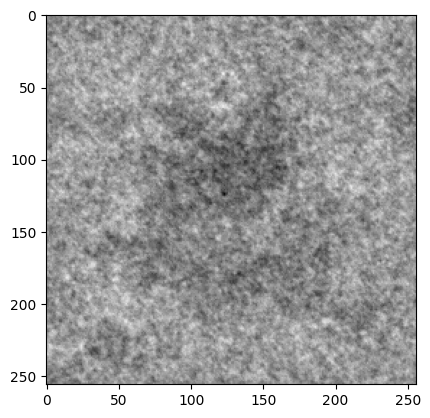

In [9]:
ds_iter = iter(ds)

img, particle = next(ds_iter)
plt.imshow(img[0], cmap="gray")

In [12]:
loader = DataLoader(
    ds,
    batch_size=512,
    num_workers=80,
    prefetch_factor=None,
    drop_last=False,
)
# iter(loader)

indices = []

for step, (idx, _) in tqdm(enumerate(loader)):
    pass

0it [00:00, ?it/s]